<a href="https://colab.research.google.com/github/marveldw/big_data/blob/main/Copy_of_Proyek_BigData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project Big Data Analytics
Analisis Interaksi dan Engagement Komentar TikTok Menggunakan PySpark dan Visualisasi Data
Notebook ini dibuat untuk memenuhi tugas Final Project Big Data Analytics dengan kombinasi:
*   Apache Spark / PySpark untuk pemrosesan data (Big Data)
*   Spark SQL untuk analisis data terstruktur

*   Visualisasi data untuk menggali insight interaksi pengguna
*   Spark MLlib untuk klasifikasi atau clustering pola komentar pengguna

Dataset: mbg_tiktokcomment.json

## 1. Latar Belakang

Platform media sosial seperti TikTok menghasilkan volume data interaksi pengguna yang sangat masif setiap detiknya. Menganalisis data komentar dapat memberikan insight yang berharga mengenai tingkat engagement audiens, waktu aktif pengguna, serta pola diskusi (komentar utama vs. balasan) pada suatu konten.

Dataset yang digunakan merupakan dataset riwayat komentar TikTok. Data ini sangat cocok digunakan untuk simulasi pemrosesan Big Data karena memiliki puluhan ribu record dengan berbagai fitur interaksi, seperti detail pengguna, waktu posting, teks komentar, struktur thread (level komentar), dan metrik balasan.

## 2. Rumusan Masalah / Business Questions

1. Kapan waktu (jam/hari) pengguna paling aktif memberikan komentar?
2. Bagaimana proporsi antara komentar utama (*root comment*) dan komentar balasan (*replies*)?
3. Siapa saja pengguna (*username*) yang paling aktif berinteraksi di dalam kolom komentar?
4. Bagaimana rata-rata panjang teks komentar (*comment length*) berdasarkan jenis komentarnya?
5. Apakah terdapat korelasi antara panjang komentar dengan probabilitas komentar tersebut mendapat balasan?
6. Apakah status jenis komentar (utama vs. balasan) dapat diprediksi menggunakan algoritma *machine learning* berdasarkan fitur panjang teks dan waktu interaksi?

## 3. Instalasi dan Import Library

Jalankan cell berikut. Jika PySpark belum tersedia, notebook akan mencoba menginstalnya secara otomatis.

In [ ]:
import sys
import subprocess
import importlib.util

if importlib.util.find_spec("pyspark") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyspark"])

import os
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, when, sum as spark_sum, avg, round as spark_round,
    year, month, date_format, to_date, desc
)

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

print("Library berhasil di-load.")

Library berhasil di-load.


## 4. Membuat Spark Session

In [ ]:
spark = SparkSession.builder \
    .appName("TikTok Comments Analysis") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark

## 5. Load Dataset

Pastikan file dataset berada dalam folder yang sama dengan notebook, atau ubah nilai `DATA_PATH` sesuai lokasi file.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, when, isnan, length,
    year, month, dayofmonth, hour, to_timestamp
)

spark = SparkSession.builder \
    .appName("TikTok Comments Analysis") \
    .getOrCreate()

DATA_PATH = "/content/drive/MyDrive/finalproject247/mbg_tiktokcomment.json"

df = spark.read \
    .option("multiline", "true") \
    .json(DATA_PATH)

print("Jumlah baris:", df.count())
print("Jumlah kolom:", len(df.columns))
df.show(5, truncate=False)

Jumlah baris: 57362
Jumlah kolom: 11
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------------------------------------------------------+-------------------+-------------------+-----+--------------------+-------------------+-------+-----------+-----------------+-------------------+
|avatar                                                                                                                                                                                                                                                                                  |comment                                                           |comment_id         |create_time        |level|nickname            |parent_comment_id  |replies|total_reply|username    

## 6. Penjelasan Dataset
Dataset terdiri dari beberapa kolom utama yang merekam aktivitas komentar:

| Kolom | Keterangan |
| :--- | :--- |
| `video_id` | ID unik dari video TikTok yang dikomentari |
| `comment_id` | ID unik untuk setiap komentar |
| `parent_comment_id` | ID komentar utama (jika baris ini adalah sebuah balasan) |
| `level` | Hierarki komentar (0 = komentar utama, 1 = balasan) |
| `username` / `nickname` | Identitas pengguna yang menulis komentar |
| `comment` | Teks isi komentar |
| `create_time` | Waktu dan tanggal komentar dipublikasikan |
| `replies` / `total_reply` | Metrik jumlah balasan yang diterima oleh sebuah komentar |

## 7. Exploratory Data Analysis

Tahap ini dilakukan untuk memahami struktur data, tipe data, jumlah record, missing value, duplikasi, dan statistik deskriptif.

In [ ]:
print("Skema Dataset:")
df.printSchema()

Skema Dataset:
root
 |-- avatar: string (nullable = true)
 |-- comment: string (nullable = true)
 |-- comment_id: string (nullable = true)
 |-- create_time: string (nullable = true)
 |-- level: string (nullable = true)
 |-- nickname: string (nullable = true)
 |-- parent_comment_id: string (nullable = true)
 |-- replies: string (nullable = true)
 |-- total_reply: string (nullable = true)
 |-- username: string (nullable = true)
 |-- video_id: string (nullable = true)



In [ ]:
print("Statistik deskriptif:")
df.describe(["level"]).show()

Statistik deskriptif:
+-------+-------------------+
|summary|              level|
+-------+-------------------+
|  count|              57362|
|   mean|0.30775584860017113|
| stddev| 0.4615717402792843|
|    min|                   |
|    max|                  1|
+-------+-------------------+



In [ ]:
print("Jumlah missing value per kolom:")

missing_df = df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
])

missing_df.show()

Jumlah missing value per kolom:
+------+-------+----------+-----------+-----+--------+-----------------+-------+-----------+--------+--------+
|avatar|comment|comment_id|create_time|level|nickname|parent_comment_id|replies|total_reply|username|video_id|
+------+-------+----------+-----------+-----+--------+-----------------+-------+-----------+--------+--------+
|     0|      0|         0|          0|    0|       0|                0|      0|          0|       0|       0|
+------+-------+----------+-----------+-----+--------+-----------------+-------+-----------+--------+--------+



In [ ]:
print("Distribusi Level Komentar:")
df.groupBy("level").count().orderBy("level").show()

Distribusi Level Komentar:
+-----+-----+
|level|count|
+-----+-----+
|     |23465|
|    0|23465|
|    1|10432|
+-----+-----+



## 8. Data Cleaning
Berdasarkan pengecekan awal, dataset perlu dibersihkan agar analisis bebas dari anomali dan struktur datanya sesuai dengan format pemrosesan PySpark.

Proses *cleaning* yang dilakukan meliputi:
* **Menghapus duplikasi:** Memastikan tidak ada data ganda berdasarkan `comment_id`.
* **Handling Missing Values:** Menghapus baris yang tidak memiliki isi teks pada kolom `comment`.
* **Casting Tipe Data:** Mengubah kolom `create_time` dari format *string* menjadi tipe *Timestamp* agar dapat diekstrak menjadi fitur waktu.

In [ ]:
df_clean = df.dropDuplicates(["comment_id"])
df_clean = df_clean.dropna(subset=["comment"])
df_clean = df_clean.withColumn("create_time", to_timestamp(col("create_time")))

print("Jumlah data setelah cleaning:", df_clean.count())
df_clean.printSchema()

Jumlah data setelah cleaning: 33897
root
 |-- avatar: string (nullable = true)
 |-- comment: string (nullable = true)
 |-- comment_id: string (nullable = true)
 |-- create_time: timestamp (nullable = true)
 |-- level: string (nullable = true)
 |-- nickname: string (nullable = true)
 |-- parent_comment_id: string (nullable = true)
 |-- replies: string (nullable = true)
 |-- total_reply: string (nullable = true)
 |-- username: string (nullable = true)
 |-- video_id: string (nullable = true)



## 9. Transformasi dan Enrichment Data
Pada tahap ini, dilakukan ekstraksi dan penambahan fitur (*feature engineering*) agar data lebih kaya dan mudah dianalisis secara temporal maupun tekstual:

* `year`: Tahun komentar diposting.
* `month`: Bulan komentar diposting.
* `day`: Tanggal komentar diposting.
* `hour`: Jam komentar diposting (digunakan untuk melihat *peak hour* interaksi).
* `comment_length`: Jumlah karakter dari teks `comment` untuk melihat pola panjang diskusi.
* `is_reply`: Fitur *flagging* numerik (1 = balasan, 0 = komentar utama) yang diturunkan dari kolom `level`.

In [ ]:
from pyspark.sql.functions import year, month, dayofmonth, hour, length, when, col

df_transformed = df_clean \
    .withColumn("year", year(col("create_time"))) \
    .withColumn("month", month(col("create_time"))) \
    .withColumn("day", dayofmonth(col("create_time"))) \
    .withColumn("hour", hour(col("create_time"))) \
    .withColumn("comment_length", length(col("comment"))) \
    .withColumn(
        "is_reply",
        when(col("level") > 0, 1).otherwise(0)
    )

df_transformed.show(5, truncate=False)

+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------------------------------------------------------------------------------+-------------------+-------------------+-----+------------+-------------------+-------+-----------+---------------+-------------------+----+-----+---+----+--------------+--------+
|avatar                                                                                                                                                                                                                                                                                  |comment                                                                          |comment_id         |create_time        |level|nickname    |parent_comment_id  |replies|total

In [ ]:
df_transformed.createOrReplaceTempView("tiktok_comments")
spark.sql("""
    SELECT
        COUNT(*) AS total_comments,
        SUM(CASE WHEN is_reply = 0 THEN 1 ELSE 0 END) AS total_main_comments,
        SUM(is_reply) AS total_replies,
        ROUND(AVG(comment_length), 2) AS avg_comment_length
    FROM tiktok_comments
""").show()

+--------------+-------------------+-------------+------------------+
|total_comments|total_main_comments|total_replies|avg_comment_length|
+--------------+-------------------+-------------+------------------+
|         33897|              23465|        10432|             67.08|
+--------------+-------------------+-------------+------------------+



## 10. Analisis 1 — Waktu Interaksi Paling Aktif (Peak Hours)

+----+--------------+
|hour|total_comments|
+----+--------------+
|   0|           948|
|   1|           493|
|   2|           316|
|   3|           241|
|   4|           415|
|   5|           994|
|   6|          1512|
|   7|          1910|
|   8|          1924|
|   9|          1709|
|  10|          1840|
|  11|          1997|
|  12|          1959|
|  13|          1510|
|  14|          1446|
|  15|          1441|
|  16|          1396|
|  17|          1228|
|  18|          1234|
|  19|          1150|
|  20|          2317|
|  21|          2645|
|  22|          2008|
|  23|          1264|
+----+--------------+



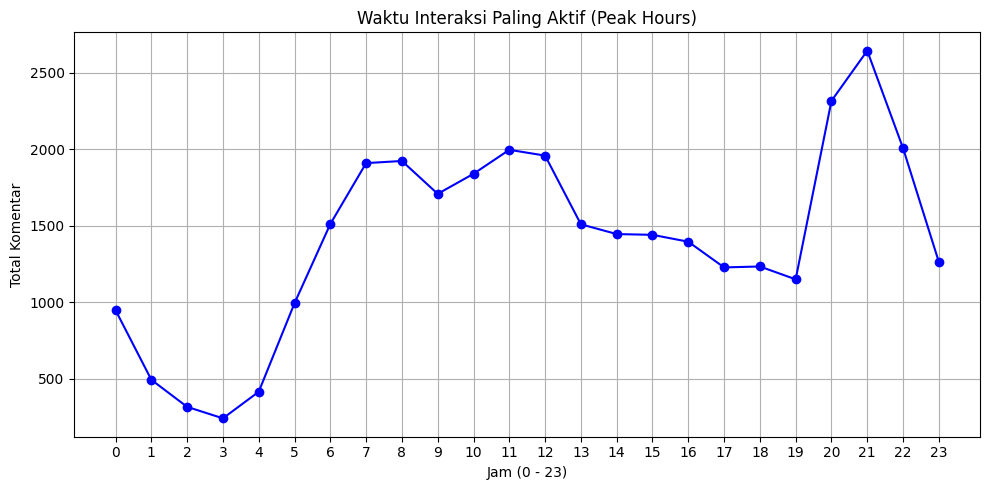

In [ ]:
peak_hours = df_transformed.groupBy("hour") \
    .agg(count("*").alias("total_comments")) \
    .orderBy("hour")

peak_hours.show(24)

peak_hours_pd = peak_hours.toPandas()
plt.figure(figsize=(10, 5))
plt.plot(peak_hours_pd["hour"], peak_hours_pd["total_comments"], marker="o", color='b')
plt.title("Waktu Interaksi Paling Aktif (Peak Hours)")
plt.xlabel("Jam (0 - 23)")
plt.ylabel("Total Komentar")
plt.grid(True)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

*Insight:* Grafik ini menunjukkan bahwa interaksi audiens (pemberian komentar) paling tinggi terjadi pada malam hari, dengan **puncak tertinggi (peak hour) pada pukul 21:00** (2.645 komentar), disusul pukul 20:00 dan 22:00. Terdapat juga lonjakan interaksi sekunder pada jam istirahat siang (pukul 11:00 - 12:00). Sebaliknya, interaksi paling sepi terjadi pada dini hari (pukul 02:00 - 04:00).


## 11. Analisis 2 — Proporsi Komentar Utama vs Balasan

+--------+-----+
|is_reply|total|
+--------+-----+
|       0|23465|
|       1|10432|
+--------+-----+



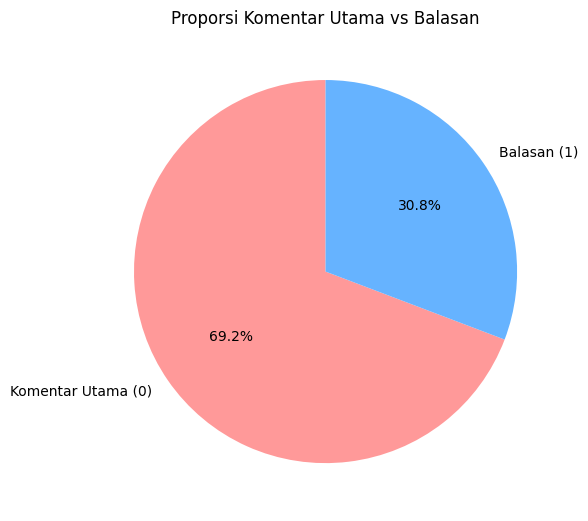

In [ ]:
# Proporsi Komentar Utama (0) vs Balasan (1)
reply_prop = df_transformed.groupBy("is_reply") \
    .agg(count("*").alias("total")) \
    .orderBy("is_reply")

reply_prop.show()

reply_prop_pd = reply_prop.toPandas()
labels = ['Komentar Utama (0)', 'Balasan (1)']

plt.figure(figsize=(6, 6))
plt.pie(reply_prop_pd["total"], labels=labels, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title("Proporsi Komentar Utama vs Balasan")
plt.tight_layout()
plt.show()

*Insight:* Grafik pie chart menunjukkan bahwa mayoritas interaksi di kolom komentar didominasi oleh **Komentar Utama (sekitar 69,2%)** dengan total 23.465 komentar, sedangkan **Balasan (sekitar 30,8%)** berjumlah 10.432 komentar.

Hal ini mengindikasikan bahwa audiens lebih cenderung mengekspresikan opini individual atau reaksi langsung terhadap video itu sendiri, dibandingkan berdiskusi atau berdebat dengan pengguna lain di dalam sebuah *thread*. Meskipun begitu, proporsi balasan yang mencapai hampir sepertiga dari total interaksi menunjukkan bahwa konten tersebut tetap berhasil memicu diskusi antar-audiens (*community engagement*) yang cukup sehat.

## 12. Analisis 3 — Pengguna Paling Aktif (Top Users)

+-----------------+--------------+
|         username|total_comments|
+-----------------+--------------+
|    fitri.ayuni66|            47|
|  kabayan.rancana|            38|
|          moonez4|            37|
|        fat_rahma|            36|
|adityapangestu771|            31|
|        taurusg33|            24|
|   richmindsetidn|            22|
|      secretbae40|            21|
|         quen_610|            20|
|       lodak.mlbb|            20|
+-----------------+--------------+



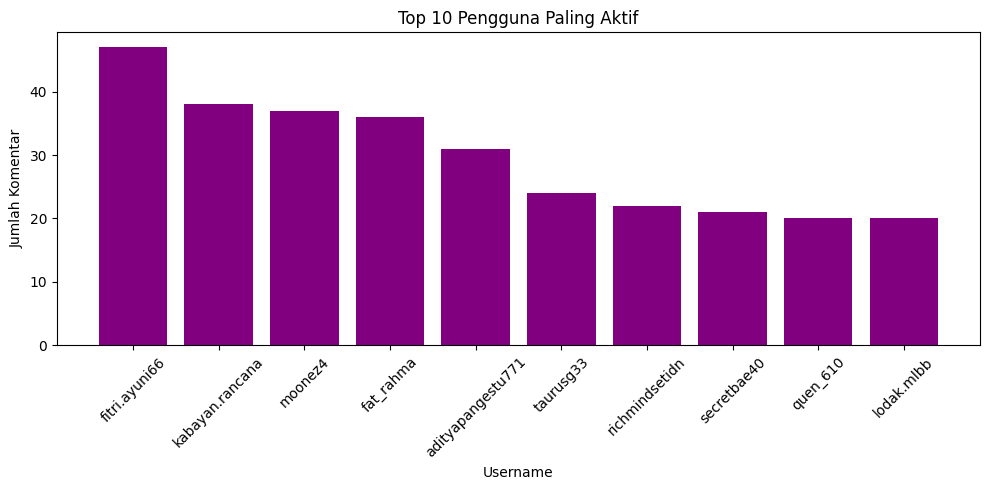

In [ ]:
from pyspark.sql.functions import desc

top_users = df_transformed.groupBy("username") \
    .agg(count("*").alias("total_comments")) \
    .orderBy(desc("total_comments")) \
    .limit(10)

top_users.show()

top_users_pd = top_users.toPandas()
plt.figure(figsize=(10, 5))
plt.bar(top_users_pd["username"], top_users_pd["total_comments"], color='purple')
plt.title("Top 10 Pengguna Paling Aktif")
plt.xlabel("Username")
plt.ylabel("Jumlah Komentar")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*Insight:* Grafik ini menunjukkan 10 pengguna yang paling aktif berinteraksi di kolom komentar. Akun **fitri.ayuni66** menduduki posisi pertama sebagai pengguna paling vokal dengan total **47 komentar**, disusul oleh **kabayan.rancana** (38 komentar) dan **moonez4** (37 komentar).

Kemunculan sekelompok kecil pengguna dengan frekuensi komentar yang tinggi ini menandakan adanya *hyper-engaged users* atau kelompok audiens yang sangat loyal di dalam konten tersebut.

## 13. Analisis 4 — Rata-Rata Panjang Teks Komentar

In [ ]:
from pyspark.sql.functions import avg, round as spark_round

avg_length = df_transformed.groupBy("is_reply") \
    .agg(spark_round(avg("comment_length"), 2).alias("avg_length")) \
    .orderBy("is_reply")

avg_length.show()

+--------+----------+
|is_reply|avg_length|
+--------+----------+
|       0|     65.27|
|       1|     71.17|
+--------+----------+



*Insight:* Berdasarkan tabel di atas, terdapat perbedaan pola pengetikan antara komentar utama dan balasan. Komentar balasan (*replies*) memiliki rata-rata teks yang lebih panjang, yaitu **71.17 karakter**, dibandingkan komentar utama (*root comments*) yang memiliki rata-rata **65.27 karakter**.

Hal ini mengindikasikan bahwa ketika pengguna membuat komentar utama, mereka cenderung memberikan reaksi spontan atau impresi singkat terhadap konten video. Namun, ketika mereka memutuskan untuk membalas komentar orang lain (`is_reply = 1`), interaksi yang terjadi cenderung lebih mendalam. Pengguna biasanya memberikan penjelasan yang lebih detail, argumen tambahan, atau sanggahan, sehingga menghasilkan teks diskusi yang lebih panjang secara karakter.

## 14. Analisis Tambahan Menggunakan Spark SQL

Spark SQL digunakan untuk menunjukkan bahwa analisis tidak hanya dilakukan dengan DataFrame API, tetapi juga dengan query SQL.

In [ ]:
spark.sql("""
    SELECT
        hour AS jam_posting,
        COUNT(*) AS total_interaksi,
        SUM(is_reply) AS jumlah_balasan,
        ROUND(AVG(comment_length), 2) AS rata_rata_panjang_teks
    FROM tiktok_comments
    GROUP BY hour
    ORDER BY total_interaksi DESC
    LIMIT 10
""").show()

+-----------+---------------+--------------+----------------------+
|jam_posting|total_interaksi|jumlah_balasan|rata_rata_panjang_teks|
+-----------+---------------+--------------+----------------------+
|         21|           2645|           724|                 73.95|
|         20|           2317|           703|                 69.99|
|         22|           2008|           564|                 71.61|
|         11|           1997|           675|                 66.36|
|         12|           1959|           607|                 65.46|
|          8|           1924|           605|                 66.15|
|          7|           1910|           541|                 68.38|
|         10|           1840|           576|                 62.12|
|          9|           1709|           574|                 65.88|
|          6|           1512|           402|                 71.58|
+-----------+---------------+--------------+----------------------+



## 15. Machine Learning — Prediksi Klasifikasi Komentar
Pada tahap ini, dilakukan analisis prediktif menggunakan *Machine Learning* untuk memprediksi apakah sebuah komentar merupakan **Balasan (1)** atau **Komentar Utama (0)**.
- **Target / Label:** `is_reply`
- **Jenis Masalah:** Klasifikasi Biner
- **Model:** Random Forest Classifier dari Spark MLlib
- **Fitur Model:** `hour`, `day`, `comment_length`

In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline

ml_df = df_transformed.select("hour", "day", "comment_length", "is_reply")

assembler = VectorAssembler(
    inputCols=["hour", "day", "comment_length"],
    outputCol="features"
)

rf = RandomForestClassifier(
    labelCol="is_reply",
    featuresCol="features",
    numTrees=50,
    maxDepth=5,
    seed=42
)

pipeline = Pipeline(stages=[assembler, rf])

train_df, test_df = ml_df.randomSplit([0.8, 0.2], seed=42)
print("Jumlah data training:", train_df.count())
print("Jumlah data testing:", test_df.count())

model = pipeline.fit(train_df)

predictions = model.transform(test_df)
predictions.select("hour", "comment_length", "is_reply", "prediction", "probability").show(10)

Jumlah data training: 27264
Jumlah data testing: 6633
+----+--------------+--------+----------+--------------------+
|hour|comment_length|is_reply|prediction|         probability|
+----+--------------+--------+----------+--------------------+
|   0|             5|       0|       0.0|[0.69343602004203...|
|   0|            23|       0|       0.0|[0.75959477157779...|
|   0|            36|       1|       0.0|[0.75743526218726...|
|   0|            18|       1|       0.0|[0.76013437324522...|
|   0|            36|       0|       0.0|[0.75743526218726...|
|   0|            23|       0|       0.0|[0.75959477157779...|
|   0|             2|       1|       0.0|[0.69189014334229...|
|   0|             3|       1|       0.0|[0.70270149850244...|
|   0|            34|       1|       0.0|[0.75743526218726...|
|   0|             9|       0|       0.0|[0.71480087191431...|
+----+--------------+--------+----------+--------------------+
only showing top 10 rows


## 16. Evaluasi Model

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

binary_evaluator = BinaryClassificationEvaluator(labelCol="is_reply", metricName="areaUnderROC")
multi_evaluator = MulticlassClassificationEvaluator(labelCol="is_reply", predictionCol="prediction")

auc = binary_evaluator.evaluate(predictions)
accuracy = multi_evaluator.evaluate(predictions, {multi_evaluator.metricName: "accuracy"})
precision = multi_evaluator.evaluate(predictions, {multi_evaluator.metricName: "weightedPrecision"})
recall = multi_evaluator.evaluate(predictions, {multi_evaluator.metricName: "weightedRecall"})
f1 = multi_evaluator.evaluate(predictions, {multi_evaluator.metricName: "f1"})

print(f"AUC       : {round(auc, 4)}")
print(f"Accuracy  : {round(accuracy, 4)}")
print(f"Precision : {round(precision, 4)}")
print(f"Recall    : {round(recall, 4)}")
print(f"F1-score  : {round(f1, 4)}")

print("\nConfusion Matrix:")
predictions.groupBy("is_reply", "prediction").count().orderBy("is_reply", "prediction").show()

AUC       : 0.6252
Accuracy  : 0.6977
Precision : 0.667
Recall    : 0.6977
F1-score  : 0.6092

Confusion Matrix:
+--------+----------+-----+
|is_reply|prediction|count|
+--------+----------+-----+
|       0|       0.0| 4453|
|       0|       1.0|  123|
|       1|       0.0| 1882|
|       1|       1.0|  175|
+--------+----------+-----+



*Interpretasi Evaluasi Model (TikTok Comments):*

Berdasarkan hasil evaluasi model Random Forest Classifier, berikut adalah insight yang didapatkan:
* **Accuracy (0.6977 / 69,77%)**: Secara keseluruhan, model berhasil menebak jenis komentar (Komentar Utama vs Balasan) dengan benar sebanyak hampir 70%.
* **AUC (0.6252)**: Kemampuan model untuk membedakan antara kelas 0 dan 1 masih berada di tingkat sedang (moderat). Angka di atas 0.5 lebih baik dari tebakan acak, namun belum cukup optimal.
* **F1-Score (0.6092)**: Skor F1 yang lebih rendah dari Accuracy mengindikasikan adanya ketidakseimbangan performa antara tebakan kelas mayoritas dan minoritas.

**Analisis Confusion Matrix:**
* Model sangat hebat dalam menebak **Komentar Utama (0)**. Dari total komentar utama, model menebak benar 4.453 komentar dan hanya salah menebak 123 komentar.
* Namun, model sangat kesulitan mendeteksi **Balasan (1)**. Dari total 2.057 balasan, model hanya berhasil menebak benar 175 balasan, dan salah menebak 1.882 balasan sebagai komentar utama.



## 17. Kesimpulan

Berdasarkan seluruh tahapan Big Data Analytics yang telah dilakukan pada dataset TikTok Comments, dapat disimpulkan beberapa poin penting berikut:

1. **Efisiensi Pemrosesan Big Data:** Dataset `mbg_tiktokcomment.json` berhasil diproses secara efisien menggunakan Apache Spark (PySpark) melalui tahapan *multiline loading*, pembersihan data duplikat berdasarkan `comment_id`, serta penanganan *missing value* selektif, menghasilkan total 33.897 records data bersih yang siap dianalisis.
2. **Pola Waktu Interaksi (Peak Hours):** Aktivitas pemberian komentar oleh audiens sangat dipengaruhi oleh faktor waktu, di mana interaksi tertinggi terjadi pada malam hari pukul 20:00 - 22:00 dengan puncak tertinggi pada pukul 21:00 (2.645 komentar). Sebaliknya, dini hari pukul 02:00 - 04:00 menjadi waktu paling sepi interaksi.
3. **Karakteristik Interaksi Komunitas:** Mayoritas interaksi di kolom komentar didominasi oleh Komentar Utama (69,2% / 23.465 data) dibandingkan Komentar Balasan (30,8% / 10.432 data). Hal ini menunjukkan audiens lebih cenderung memberikan reaksi spontan terhadap video daripada berdiskusi panjang antar-pengguna.
4. **Identifikasi Audiens Loyal (Top Users):** Analisis berhasil memetakan adanya kelompok *hyper-engaged users* atau audiens yang sangat vokal di dalam komunitas, yang dipimpin oleh akun **fitri.ayuni66** dengan total kontribusi sebanyak 47 komentar.
5. **Kedalaman Diskusi Terhadap Panjang Teks:** Terdapat perbedaan pola pengetikan yang signifikan di mana komentar balasan (*replies*) memiliki rata-rata teks lebih panjang (71,17 karakter) dibandingkan komentar utama (65,27 karakter). Ini menandakan adanya diskusi yang lebih mendalam saat audiens saling menanggapi komentar.
6. **Optimasi Analisis dengan Spark SQL:** Melalui query Spark SQL, ditemukan korelasi kuat antara volume interaksi dan kedalaman teks; jam sibuk pada pukul 21:00 tidak hanya menghasilkan jumlah komentar terbanyak, tetapi juga menghasilkan teks dengan rata-rata terpanjang (73,95 karakter).
7. **Performa Pemodelan Machine Learning:** Model Random Forest Classifier dari Spark MLlib berhasil dibangun menggunakan fitur temporal dan tekstual (`hour`, `day`, `comment_length`) dengan performa akurasi keseluruhan (*Accuracy*) mencapai 69,77% dan nilai AUC sebesar 0.6252.
8. **Tantangan Class Imbalance pada Evaluasi Model:** Berdasarkan *Confusion Matrix*, model mengalami ketimpangan performa akibat dominasi kelas mayoritas (*class imbalance*). Model sangat akurat dalam mendeteksi Komentar Utama (4.453 benar), namun sangat kesulitan mendeteksi Komentar Balasan (hanya 175 benar), sehingga menahan nilai F1-score di angka 0.6092.

## 20. Saran Pengembangan

Untuk meningkatkan kualitas analisis dan akurasi model di masa mendatang, beberapa pengembangan yang direkomendasikan adalah:

1. **Penerapan Natural Language Processing (NLP):** Menggunakan teknik TF-IDF atau *Word Embeddings* (Word2Vec) untuk mengekstrak makna dari teks komentar, bukan hanya sekadar menghitung panjang karakternya.
2. **Analisis Sentimen (Sentiment Analysis):** Mengklasifikasikan isi komentar ke dalam sentimen Positif, Negatif, atau Netral untuk melihat reaksi emosional audiens terhadap video.
3. **Penanganan Class Imbalance:** Menerapkan teknik *Oversampling* (seperti SMOTE), *Undersampling*, atau *Class Weighting* pada pipeline Machine Learning agar model lebih pintar dalam mendeteksi Komentar Balasan (minoritas).
4. **Topic Modeling:** Menggunakan algoritma seperti Latent Dirichlet Allocation (LDA) untuk mengelompokkan komentar dan mengetahui topik apa yang paling banyak diperdebatkan oleh audiens.

In [ ]:
spark.stop()
print("Spark session dihentikan. Proses Big Data Analytics selesai.")